# P&C Claims Affordability Analysis
## Can a motor insurer pay its claims from current premium intake?

**Data:** CAS Schedule P — NAIC Private Passenger Auto (1998–2007)  
**Tools:** MySQL · R · Python  
**Author:** Aspiring Actuarial Analyst

---

### Business question

Given real premium and claims data from 101 US private passenger auto insurers,
can each insurer fund its current and projected future claims obligations from premium alone?

This notebook walks through the complete actuarial analysis — from raw data to rate recommendations.

---
## Section 1 — Data and methodology

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

PROJECT_DIR = r'C:\Users\User\Documents\pc-claims-affordability'
os.chdir(PROJECT_DIR)

# Load all processed datasets
industry    = pd.read_csv('data/processed/industry_summary.csv')
scorecard   = pd.read_csv('data/processed/insurer_scorecard.csv')
dev_curve   = pd.read_csv('data/processed/development_curve.csv')
rate_adeq   = pd.read_csv('data/processed/rate_adequacy.csv')
link_ratios = pd.read_csv('data/processed/link_ratios.csv')
bf_results  = pd.read_csv('data/processed/bf_results.csv')
sensitivity = pd.read_csv('data/processed/sensitivity_analysis.csv')

print('Datasets loaded:')
print(f'  Industry summary:   {len(industry)} accident years')
print(f'  Insurer scorecard:  {len(scorecard)} insurers')
print(f'  Development curve:  {len(dev_curve)} lags')
print(f'  Rate adequacy:      {len(rate_adeq)} years')

Datasets loaded:
  Industry summary:   10 accident years
  Insurer scorecard:  101 insurers
  Development curve:  10 lags
  Rate adequacy:      10 years


### Dataset overview

The CAS Schedule P dataset contains regulatory filings from US property-casualty insurers submitted to the NAIC.
It covers **101 single-entity private passenger auto insurers** across **10 accident years (1998–2007)**
with **10 development lags** per year — giving a complete 10×10 loss development triangle.

Each row contains:
- **Earned premium** (net of reinsurance)
- **Cumulative paid losses** at each development lag
- **Incurred losses** (paid + case reserves)
- **Bulk & IBNR reserves**

**Key assumption:** An expense load of 28.5% of premium (FER 16% + VER 12.5%) is applied throughout,
consistent with US private passenger auto industry benchmarks.

---
## Section 2 — Industry loss ratio analysis

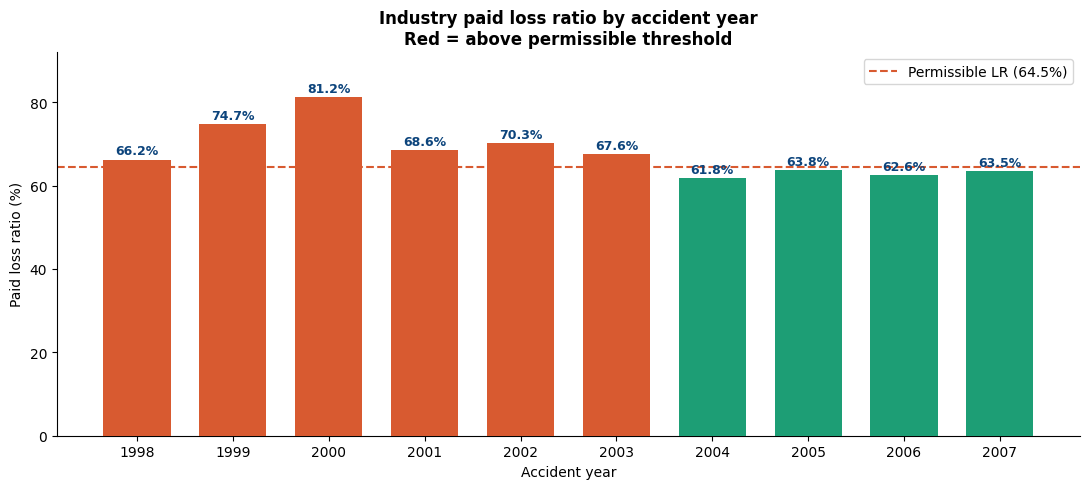

Best year:  AY2004 (61.8%)
Worst year: AY2000 (81.2%)
Years above permissible: 6 of 10


In [2]:
BLUE_DARK  = '#0C447C'
TEAL       = '#1D9E75'
CORAL      = '#D85A30'
BLUE_LIGHT = '#B5D4F4'
GRAY       = '#888780'
AMBER      = '#BA7517'

fig, ax = plt.subplots(figsize=(11, 5))

colors = [CORAL if lr > 64.5 else TEAL
          for lr in industry['paid_loss_ratio']]

bars = ax.bar(industry['AccidentYear'],
              industry['paid_loss_ratio'],
              color=colors, width=0.7, zorder=3)

ax.axhline(y=64.5, color=CORAL, linewidth=1.5,
           linestyle='--', label='Permissible LR (64.5%)')

for bar, val in zip(bars, industry['paid_loss_ratio']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color=BLUE_DARK)

ax.set_xlabel('Accident year')
ax.set_ylabel('Paid loss ratio (%)')
ax.set_title('Industry paid loss ratio by accident year\n'
             'Red = above permissible threshold',
             fontweight='bold')
ax.set_xticks(industry['AccidentYear'])
ax.set_ylim(0, 92)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Best year:  AY{industry.loc[industry['paid_loss_ratio'].idxmin(), 'AccidentYear']}"
      f" ({industry['paid_loss_ratio'].min():.1f}%)")
print(f"Worst year: AY{industry.loc[industry['paid_loss_ratio'].idxmax(), 'AccidentYear']}"
      f" ({industry['paid_loss_ratio'].max():.1f}%)")
print(f"Years above permissible: "
      f"{(industry['paid_loss_ratio'] > 64.5).sum()} of 10")

**Insight:** Six of ten accident years show a paid loss ratio above the permissible threshold of 64.5%.
The crisis is most severe in 1999–2000 where loss ratios reached 74.7% and 81.2% respectively.
The market recovered strongly from 2004 onwards following aggressive rate increases.

---
## Section 3 — Funding surplus and deficit

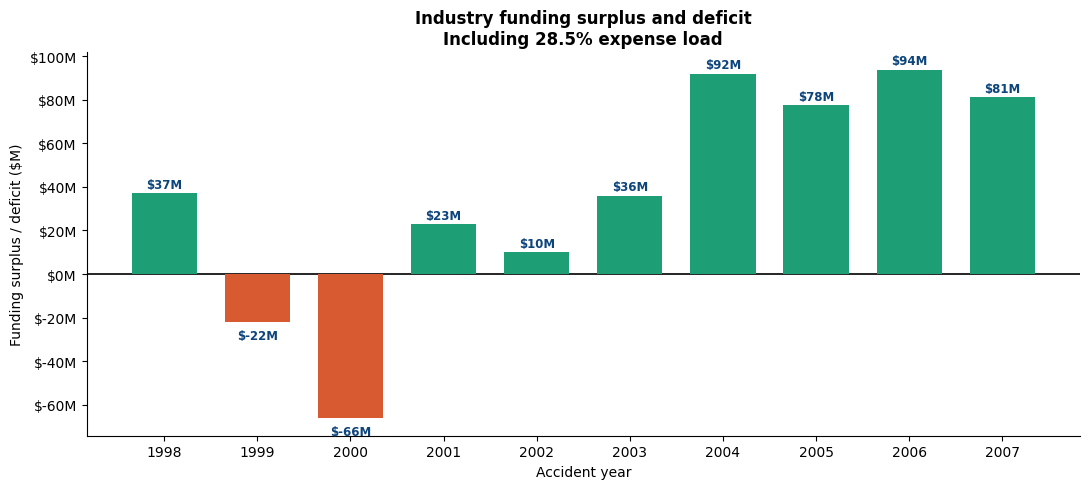

Total deficit years: $-88M
Total surplus years: $452M
Net position:        $363M


In [3]:
fig, ax = plt.subplots(figsize=(11, 5))

surplus = industry['funding_surplus_deficit']
colors2 = [TEAL if v >= 0 else CORAL for v in surplus]

bars = ax.bar(industry['AccidentYear'],
              surplus / 1000,
              color=colors2, width=0.7, zorder=3)

ax.axhline(y=0, color='black', linewidth=1.2)

for bar, val in zip(bars, surplus / 1000):
    ypos = val + 1 if val >= 0 else val - 3
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'${val:.0f}M',
            ha='center',
            va='bottom' if val >= 0 else 'top',
            fontsize=8.5, fontweight='bold', color=BLUE_DARK)

ax.set_xlabel('Accident year')
ax.set_ylabel('Funding surplus / deficit ($M)')
ax.set_title('Industry funding surplus and deficit\n'
             'Including 28.5% expense load',
             fontweight='bold')
ax.set_xticks(industry['AccidentYear'])
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

total_deficit = surplus[surplus < 0].sum() / 1000
total_surplus = surplus[surplus > 0].sum() / 1000
print(f'Total deficit years: ${total_deficit:.0f}M')
print(f'Total surplus years: ${total_surplus:.0f}M')
print(f'Net position:        ${(total_deficit + total_surplus):.0f}M')

**Insight:** The industry funding deficit peaked at **-$66M in 2000** — meaning the entire market collectively
paid out $66 million more in claims and expenses than it collected in premium that year.
The net position across all 10 years is positive, confirming the market corrected successfully —
but only after two years of significant losses.

---
## Section 4 — Loss development curve

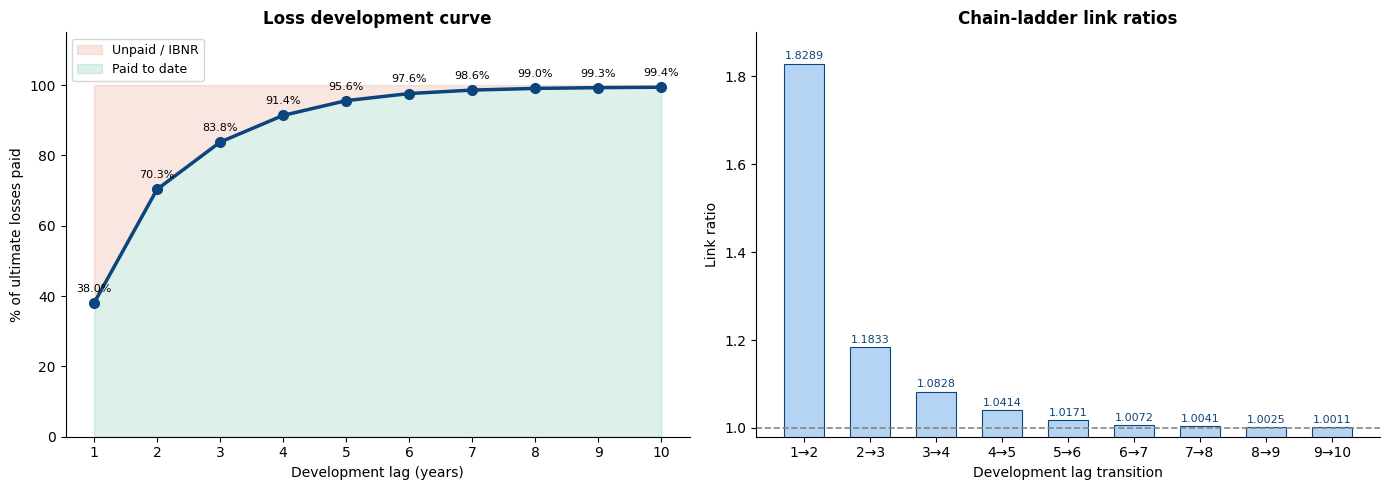

At lag 1, only 38.0% of ultimate claims are paid
The lag 1→2 link ratio of 1.8289 means claims nearly double in year 2


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: development curve
ax = axes[0]
ax.plot(dev_curve['DevelopmentLag'],
        dev_curve['pct_paid_of_incurred'],
        color=BLUE_DARK, linewidth=2.5,
        marker='o', markersize=7)
ax.fill_between(dev_curve['DevelopmentLag'],
                dev_curve['pct_paid_of_incurred'],
                100, alpha=0.15, color=CORAL,
                label='Unpaid / IBNR')
ax.fill_between(dev_curve['DevelopmentLag'],
                0, dev_curve['pct_paid_of_incurred'],
                alpha=0.15, color=TEAL,
                label='Paid to date')
for _, row in dev_curve.iterrows():
    ax.annotate(f"{row['pct_paid_of_incurred']:.1f}%",
                xy=(row['DevelopmentLag'],
                    row['pct_paid_of_incurred']),
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=8)
ax.set_xlabel('Development lag (years)')
ax.set_ylabel('% of ultimate losses paid')
ax.set_title('Loss development curve', fontweight='bold')
ax.set_xticks(dev_curve['DevelopmentLag'])
ax.set_ylim(0, 115)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Right: link ratios
ax2 = axes[1]
x_labels = [f"{int(r['from_lag'])}→{int(r['to_lag'])}"
            for _, r in link_ratios.iterrows()]
ax2.bar(x_labels, link_ratios['link_ratio'],
        color=BLUE_LIGHT, edgecolor=BLUE_DARK,
        linewidth=0.8, width=0.6)
ax2.axhline(y=1.0, color=GRAY, linewidth=1.2, linestyle='--')
for i, (x, val) in enumerate(zip(x_labels,
                                  link_ratios['link_ratio'])):
    ax2.text(i, val + 0.005, f'{val:.4f}',
             ha='center', va='bottom',
             fontsize=8, color=BLUE_DARK)
ax2.set_xlabel('Development lag transition')
ax2.set_ylabel('Link ratio')
ax2.set_title('Chain-ladder link ratios', fontweight='bold')
ax2.set_ylim(0.98, 1.90)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f"At lag 1, only {dev_curve['pct_paid_of_incurred'].iloc[0]:.1f}%"
      f" of ultimate claims are paid")
print(f"The lag 1→2 link ratio of "
      f"{link_ratios['link_ratio'].iloc[0]:.4f} means "
      f"claims nearly double in year 2")

**Insight:** The development curve shows the classic private passenger auto pattern —
steep early development (38% paid by lag 1, 70% by lag 2) followed by a long slow tail.
The lag 1→2 link ratio of 1.83 is the most critical number in reserving:
an insurer looking at year-end lag 1 data is only seeing 38 cents of every ultimate claims dollar.

---
## Section 5 — Insurer solvency analysis

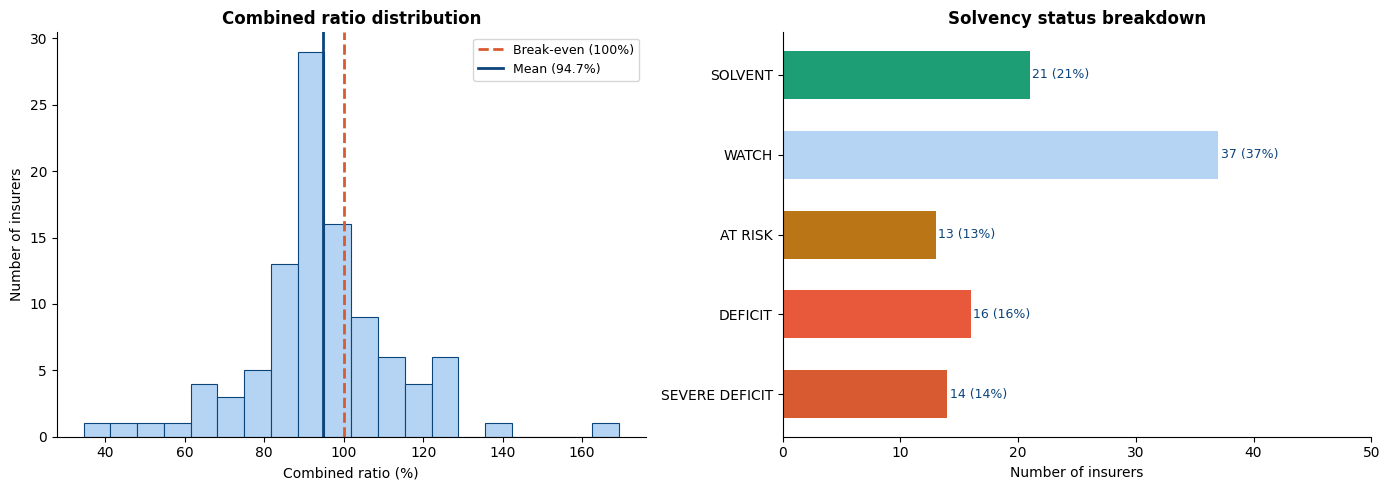

Insurers with combined ratio > 100%: 30
Insurers fully solvent: 21
Worst combined ratio: Old American Cty Mut Fire Ins Co at 169.2%


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: combined ratio distribution
ax = axes[0]
ax.hist(scorecard['combined_ratio'], bins=20,
        color=BLUE_LIGHT, edgecolor=BLUE_DARK,
        linewidth=0.8)
ax.axvline(x=100, color=CORAL, linewidth=2,
           linestyle='--', label='Break-even (100%)')
ax.axvline(x=scorecard['combined_ratio'].mean(),
           color=BLUE_DARK, linewidth=2,
           label=f"Mean ({scorecard['combined_ratio'].mean():.1f}%)")
ax.set_xlabel('Combined ratio (%)')
ax.set_ylabel('Number of insurers')
ax.set_title('Combined ratio distribution', fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Right: solvency status counts
ax2 = axes[1]
status_order  = ['SEVERE DEFICIT', 'DEFICIT',
                 'AT RISK', 'WATCH', 'SOLVENT']
status_counts = scorecard['solvency_status'].value_counts()
status_counts = status_counts.reindex(
    [s for s in status_order if s in status_counts.index])
colors_s = [CORAL, '#E8593C', AMBER, BLUE_LIGHT, TEAL]
bars = ax2.barh(status_counts.index,
                status_counts.values,
                color=colors_s[:len(status_counts)],
                height=0.6)
for bar, val in zip(bars, status_counts.values):
    ax2.text(val + 0.2,
             bar.get_y() + bar.get_height()/2,
             f'{val} ({val/len(scorecard)*100:.0f}%)',
             va='center', fontsize=9, color=BLUE_DARK)
ax2.set_xlabel('Number of insurers')
ax2.set_title('Solvency status breakdown', fontweight='bold')
ax2.set_xlim(0, 50)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

deficit = scorecard[scorecard['combined_ratio'] > 100]
print(f'Insurers with combined ratio > 100%: {len(deficit)}')
print(f'Insurers fully solvent: '
      f"{(scorecard['solvency_status'] == 'SOLVENT').sum()}")
print(f'Worst combined ratio: '
      f"{scorecard['GRNAME'].iloc[0]} at "
      f"{scorecard['combined_ratio'].iloc[0]:.1f}%")

**Insight:** When expenses are included, **30 of 101 insurers have a combined ratio above 100%** —
they are paying out more than they collect. Only 21 insurers are genuinely solvent with a
comfortable margin. Old American Cty Mut Fire Ins Co is the most distressed at 169.2%.

---
## Section 6 — Rate adequacy

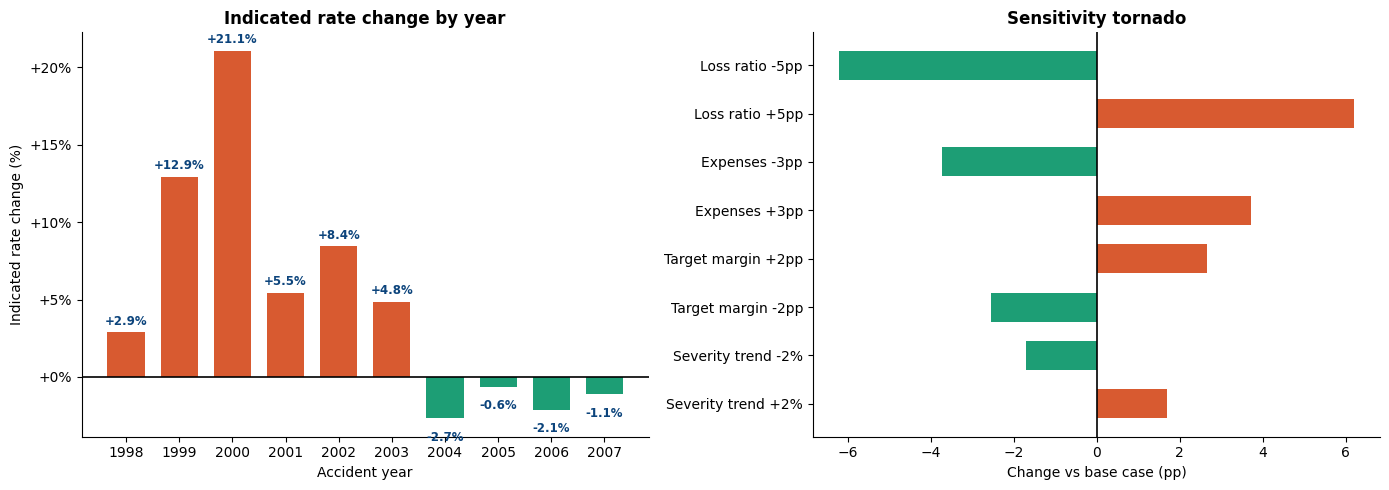

Permissible loss ratio: 64.5%
Years needing increase: 6 of 10
Largest indication: +21.1% (AY2000)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: indicated rate change
ax = axes[0]
colors_r = [CORAL if v > 0 else TEAL
            for v in rate_adeq['indicated_change']]
bars = ax.bar(rate_adeq['AccidentYear'],
              rate_adeq['indicated_change'] * 100,
              color=colors_r, width=0.7)
ax.axhline(y=0, color='black', linewidth=1.2)
for bar, val in zip(bars, rate_adeq['indicated_change'] * 100):
    ypos = val + 0.3 if val >= 0 else val - 0.8
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'{val:+.1f}%', ha='center',
            va='bottom' if val >= 0 else 'top',
            fontsize=8.5, fontweight='bold', color=BLUE_DARK)
ax.set_xlabel('Accident year')
ax.set_ylabel('Indicated rate change (%)')
ax.set_title('Indicated rate change by year', fontweight='bold')
ax.set_xticks(rate_adeq['AccidentYear'])
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:+.0f}%'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Right: sensitivity tornado
ax2 = axes[1]
base_ind = sensitivity.loc[
    sensitivity['Scenario'] == 'Base case',
    'Indicated_Change'].values[0]
sens = sensitivity[sensitivity['Scenario'] != 'Base case'].copy()
sens['delta'] = (sens['Indicated_Change'] - base_ind) * 100
sens = sens.sort_values('delta', key=abs, ascending=True)
colors_t = [CORAL if v > 0 else TEAL for v in sens['delta']]
ax2.barh(sens['Scenario'], sens['delta'],
         color=colors_t, height=0.6)
ax2.axvline(x=0, color='black', linewidth=1.2)
ax2.set_xlabel('Change vs base case (pp)')
ax2.set_title('Sensitivity tornado', fontweight='bold')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print('Permissible loss ratio: 64.5%')
print(f"Years needing increase: "
      f"{(rate_adeq['indicated_change'] > 0).sum()} of 10")
print(f"Largest indication: "
      f"+{rate_adeq['indicated_change'].max()*100:.1f}% "
      f"(AY{rate_adeq.loc[rate_adeq['indicated_change'].idxmax(), 'AccidentYear']})")

**Insight:** Six of ten accident years required rate increases. The largest was **+21.1% in AY2000**.
The sensitivity analysis shows that the loss ratio assumption drives the indication most strongly —
a 5 percentage point increase in the projected loss ratio adds approximately 6pp to the indicated change.

---
## Section 7 — Stress test

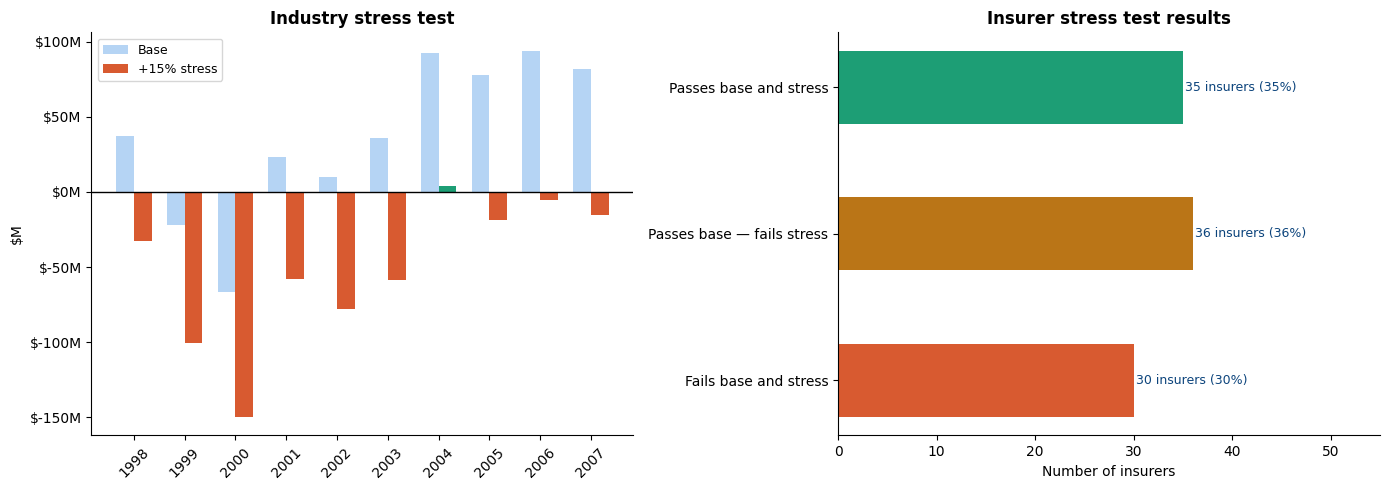

Insurers passing both base and stress: 35 of 101 (35%)
Only AY2004 passes industry-level stress test


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: industry stress test
ax = axes[0]
x = np.arange(len(industry))
w = 0.35
base     = industry['funding_surplus_deficit'] / 1000
stressed = (industry['funding_surplus_deficit'] -
            industry['paid_claims'] * 0.15) / 1000
ax.bar(x - w/2, base, w, label='Base', color=BLUE_LIGHT)
ax.bar(x + w/2, stressed, w, label='+15% stress',
       color=[CORAL if v < 0 else TEAL for v in stressed])
ax.axhline(y=0, color='black', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(industry['AccidentYear'], rotation=45)
ax.set_ylabel('$M')
ax.set_title('Industry stress test', fontweight='bold')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Right: insurer stress test pass/fail
ax2 = axes[1]
stress_order = ['Fails base and stress',
                'Passes base — fails stress',
                'Passes base and stress']
sc = scorecard['stress_test_result'].value_counts()
sc = sc.reindex([s for s in stress_order if s in sc.index])
colors_st = [CORAL, AMBER, TEAL]
bars = ax2.barh(sc.index, sc.values,
                color=colors_st[:len(sc)], height=0.5)
for bar, val in zip(bars, sc.values):
    ax2.text(val + 0.2,
             bar.get_y() + bar.get_height()/2,
             f'{val} insurers ({val/len(scorecard)*100:.0f}%)',
             va='center', fontsize=9, color=BLUE_DARK)
ax2.set_xlabel('Number of insurers')
ax2.set_title('Insurer stress test results', fontweight='bold')
ax2.set_xlim(0, 55)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

pass_both = (scorecard['stress_test_result'] ==
             'Passes base and stress').sum()
print(f'Insurers passing both base and stress: '
      f'{pass_both} of {len(scorecard)} ({pass_both/len(scorecard)*100:.0f}%)')
print(f'Only AY2004 passes industry-level stress test')

**Insight:** Only **35 of 101 insurers (35%)** pass both the base and stress tests.
At the industry level, only AY2004 survives a 15% severity shock.
This confirms the market was consistently under-capitalised throughout 1998–2007,
even during the apparent recovery years of 2004–2007.

---
## Section 8 — Key findings summary

| Finding | Key number |
|---|---|
| Total earned premium (10yr) | $8.7 billion |
| Average paid loss ratio | 66.8% |
| Industry funding deficit peak | -$66M (AY2000) |
| Years requiring rate increase | 6 of 10 |
| Largest indicated rate increase | +21.1% (AY2000) |
| Insurers in severe deficit | 14 (13.9%) |
| Insurers fully solvent | 21 (20.8%) |
| Pass stress test (+15%) | 35 of 101 (34.7%) |
| Total BF IBNR (AY1998–2003) | $590M |
| Lag 1→2 link ratio | 1.8289 |

### Conclusion

The US private passenger auto insurance market was **systematically underpriced** for the majority
of the 1998–2007 period. Premium intake was insufficient to fund claims and expenses in 1999 and 2000,
and only marginally adequate in 2002. The Bornhuetter-Ferguson IBNR analysis independently confirms
that 1998–2000 reserves were inadequate at the time they were set.

The core lesson: **annual actuarial rate reviews and reserve monitoring are not optional**.
The $89 million combined deficit in 1999–2000 was not inevitable — it was the cost of
inadequate pricing discipline.